In [1]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

In [2]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("iabhishekofficial/mobile-price-classification")

print("Path to dataset files:", path)

/home/waroon/SecondYear/FirstSemester/IntroMLHomework/Week10/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /home/waroon/.cache/kagglehub/datasets/iabhishekofficial/mobile-price-classification/versions/1


In [3]:
import pandas as pd

train = pd.read_csv(os.path.join(path, "train.csv"))
test = pd.read_csv(os.path.join(path, "test.csv"))

print(train.head())
print(test.head())

   battery_power  blue  clock_speed  dual_sim  fc  four_g  int_memory  m_dep  \
0            842     0          2.2         0   1       0           7    0.6   
1           1021     1          0.5         1   0       1          53    0.7   
2            563     1          0.5         1   2       1          41    0.9   
3            615     1          2.5         0   0       0          10    0.8   
4           1821     1          1.2         0  13       1          44    0.6   

   mobile_wt  n_cores  ...  px_height  px_width   ram  sc_h  sc_w  talk_time  \
0        188        2  ...         20       756  2549     9     7         19   
1        136        3  ...        905      1988  2631    17     3          7   
2        145        5  ...       1263      1716  2603    11     2          9   
3        131        6  ...       1216      1786  2769    16     8         11   
4        141        2  ...       1208      1212  1411     8     2         15   

   three_g  touch_screen  wifi  price_

#### CSV Dataset

In [4]:
# Load mobile price dataset into dataframe
mobile_df = pd.read_csv(os.path.join(path, "train.csv")).dropna()
print(mobile_df.price_range.unique())
mobile_df.head()

[1 2 3 0]


,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [5]:
# Seperate features and target
mb_X = mobile_df.drop(columns=['price_range']).values.astype(np.float32)
mb_y = mobile_df.price_range.values

# Standardize features
scaler = StandardScaler()
mb_X = scaler.fit_transform(mb_X)
# ^^^^^^^^

# Convert to tensors
mb_X = torch.tensor(mb_X)
mb_y = torch.tensor(mb_y)

# Create train and test datasets
mb_train_set = TensorDataset(mb_X, mb_y)
train_split = 0.8
mb_train_size = int(train_split * len(mb_train_set))
mb_test_size = len(mb_train_set) - mb_train_size
mb_train_set, mb_test_set = torch.utils.data.random_split(mb_train_set, [mb_train_size, mb_test_size])

# Create dataloaders
mb_train_loader = DataLoader(mb_train_set, batch_size=16, shuffle=True)
mb_test_loader = DataLoader(mb_test_set, batch_size=16, shuffle=True)

print(len(mb_train_set), len(mb_test_set))
print(len(mb_train_loader), len(mb_test_loader))

1600 400
100 25


#### Functions and Models for use

In [6]:
class MLP_CSV(nn.Module):
    def __init__(self):
        super(MLP_CSV, self).__init__()
        self.fc1 = nn.Sequential(
            nn.Linear(in_features=20, out_features=128), # 20 input features
            nn.ReLU(),
        )
        self.fc2 = nn.Sequential(
            nn.Linear(in_features=128, out_features=64),
            nn.ReLU(),
        )
        self.fc3 = nn.Sequential(
            nn.Linear(in_features=64, out_features=32),
            nn.ReLU(),
        )
        self.out = nn.Linear(in_features=32, out_features=4)  # 4 output for classification

    def forward(self, x):
        x = self.fc1(x)
        x = self.fc2(x)
        x = self.fc3(x)
        x = self.out(x)
        return x

class MLP_MNIST(nn.Module):
    def __init__(self):
        super(MLP_MNIST, self).__init__()
        self.fc1 = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=8*8, out_features=32), # 8*8 = 64 resized input pixels
            nn.ReLU(),
        )
        self.fc2 = nn.Sequential(
            nn.Linear(in_features=32, out_features=24),
            nn.ReLU(),
        )
        self.fc3 = nn.Sequential(
            nn.Linear(in_features=24, out_features=16),
            nn.ReLU(),
        )
        self.out = nn.Linear(in_features=16, out_features=10)  # 10 output for numbers

    def forward(self, x):
        x = self.fc1(x)
        x = self.fc2(x)
        x = self.fc3(x)
        x = self.out(x)
        return x

In [7]:
def training_loop(train_dl, test_dl, model, n_epochs=200):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    # Your optimizer and loss function
    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    loss_fn = nn.CrossEntropyLoss()
    # ^^^^^^^^

    n_show_loss = n_epochs // 10 if n_epochs > 10 else 1
    train_history = {"train_loss":[], "validate_loss":[],
                     "train_acc":[], "validate_acc":[]}
    # Begin training loop
    for epoch in range(n_epochs):
        # Train loop
        train_loss, train_correct = 0, 0
        model.train(True)
        for X_t, y_t in train_dl:
            X_t, y_t = X_t.to(device), y_t.to(device)
            optimizer.zero_grad()
            y_pred = model(X_t)
            # This is your training loss calculation
            loss = loss_fn(y_pred, y_t)
            loss.backward()
            # ^^^^^^^^
            optimizer.step()
            train_loss += loss.item()
            train_correct += (y_pred.argmax(1) == y_t).float().sum().item()
        train_history["train_loss"].append(train_loss / len(train_dl))
        train_history["train_acc"].append(train_correct / len(train_dl.dataset))

        # Test loop
        valid_loss, valid_correct = 0, 0
        model.eval()
        with torch.no_grad():
            for X_v, y_v in test_dl:
                X_v, y_v = X_v.to(device), y_v.to(device)
                y_predv = model(X_v)
                vloss = loss_fn(y_predv.squeeze(), y_v.squeeze())
                valid_loss += vloss.item()
                valid_correct += (y_predv.argmax(1) == y_v).float().sum().item()
        train_history["validate_loss"].append(valid_loss / len(test_dl))
        train_history["validate_acc"].append(valid_correct / len(test_dl.dataset))

        if ((epoch+1) % n_show_loss == 0) or (epoch == n_epochs-1):
            print(f"Epochs {epoch+1}".ljust(12),
                  f"train loss {train_history['train_loss'][-1]:.6f}",
                  f"valid loss {train_history['validate_loss'][-1]:.6f}",
                  f"train acc {train_history['train_acc'][-1]:.6f}",
                  f"valid acc {train_history['validate_acc'][-1]:.6f}")

    return train_history

def plot_result(history):
    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.set_figwidth(10)
    fig.suptitle("Train vs Validation")
    ax1.plot(history["train_acc"], label="Train")
    ax1.plot(history["validate_acc"], label="Validation")
    ax1.legend()
    ax1.set_title("Accuracy")

    ax2.plot(history["train_loss"], label="Train")
    ax2.plot(history["validate_loss"], label="Validation")
    ax2.legend()
    ax2.set_title("Loss")
    fig.show()


----
## HW
----
### - CSV Dataset
Mobile price dataset ที่กำหนดมีข้อมูลเบื้องต้น ดังนี้
- จำนวน Features = 20 (RAM, Internal memory, Battery, ...)
- Target คือ `price_range` โดยมีทั้งหมด 4 ค่า คือ 0, 1, 2, 3 (Low cost, Medium cost, High cost, Very high cost)

> กำหนดให้ใช้โมเดล `MLP_CSV` เป็นต้นแบบ การ train ให้ใช้จำนวน `epochs` = 200, `optimizer` = Adam, `learning_rate` = 0.0001, `train_split` = 0.8, `batch_size` = 16, ไม่ใช้ Learning rate scheduler

'

1.) ให้ทดลอง train โมเดลโดยใช้ training loop ที่ให้มาหรือเขียนขึ้นเอง แบบธรรมดาไม่มีการปรับเพิ่มเติม ใช้เพื่อเป็นผลลัพธ์ Baseline สำหรับข้อต่อ ๆ ไป

- > แคปรูปผลลัพธ์ใหม่ 1 รูป

2.) ให้ทดลอง train โมเดลโดยใช้ L2 Regularizer เพิ่มในข้อ 1.) รวมทั้งหมด 2 แบบ คือ
  1. ใช้ L2 แบบ Marginal loss โดย `lambda` = [0.03, 0.01, 0.005] (เพิ่ม L2 loss ใน Training loop)
  2. ใช้ L2 แบบ Weight decay โดย `weight_decay` = [0.06, 0.01, 0.005] (ปรับ param ใน `optimizer`)

- > แคปรูปผลลัพธ์ใหม่ทั้งหมด 6 รูป พร้อมกับแสดงส่วนที่แก้ไขเพื่อทำ Marginal loss ภายใน Training loop และ วิเคราะห์เปรียบเทียบผลลัพธ์ที่ได้ทั้งหมดกับข้อ 1.)

3.) ให้ทดลอง train โมเดลโดยใช้ Dropout เพิ่มในข้อ 1.) ภายในชั้น fc1, fc2 และ fc3 และแทนค่า `p` ในแต่ละชั้นเป็นค่าดังต่อไปนี้
  1. fc1, fc2, fc3 = 0.5, 0.3, 0.2
  2. fc1, fc2, fc3 = 0.3, 0.2, 0.1
  3. fc1, fc2, fc3 = 0.2, 0.2, 0.2

- > แคปรูปผลลัพธ์ใหม่ทั้งหมด 3 รูป และ วิเคราะห์เปรียบเทียบผลลัพธ์ที่ได้กับข้อ 1.)

4.) ให้ทดลอง train โมเดล `MLP_CSV` ต้นแบบจากข้อ 1.) อีกครั้ง พร้อมกับ train โมเดลที่ใช้ BatchNorm เพิ่มในข้อ 1.) ภายในชั้น fc1, fc2 และ fc3 (ใช้ `nn.BatchNorm1d`) แต่จะมีการปรับในส่วนการเตรียม Mobile price Dataset ดังนี้
  1. โมเดลที่ใช้ BatchNorm ใช้ Dataset ที่ **ผ่าน** การทำ Standardized ด้วย `StandardScaler()` เทียบกับผลลัพธ์ข้อ 1.)
  2. โมเดล `MLP_CSV` ต้นแบบจากข้อ 1.) ใช้ Dataset ที่ **ไม่ผ่าน** การทำ Standardized
  3. โมเดลที่ใช้ BatchNorm ใช้ Dataset ที่ **ไม่ผ่าน** การทำ Standardized เทียบกับผลลัพธ์ข้อ 4.2)

- > แคปรูปผลลัพธ์ใหม่ทั้งหมด 3 รูป และ วิเคราะห์เปรียบเทียบผลลัพธ์ที่ได้

'

----

### - Torchvision Dataset

MNIST dataset จาก torchvision
- ภาพตัวเลขเขียนด้วยลายมือ
- ขนาด 28x28 pixel จะได้จำนวน features = 784
- Target = เลข 0 - 9 (10 ตัว)

```python
import torchvision
from torchvision import transforms
from torchvision.transforms import v2
import ...

# Your own transform
transforms = v2.Compose([
                v2.ToImage(),
                v2.ToDtype(torch.float32, scale=True),
                ...,
                ...])

# Optimizer, criterion (loss), and other hyper-pars
# model = ...
# optimizer = ...
# criterion = ...
# batch_size = ...
# scheduler = ...
# other = ...

# Download train-valid(test) Dataset
mnist_train_data = torchvision.datasets.MNIST('./Image/train_directory/', transform=transforms, download=True, train=True)
mnist_train_loader = torch.utils.data.DataLoader(mnist_train_data, batch_size=batch_size, shuffle=True)

mnist_test_data = torchvision.datasets.MNIST('./Image/test_directory/', transform=transforms, download=True, train=False)
mnist_valid_loader = torch.utils.data.DataLoader(mnist_test_data, batch_size=batch_size, shuffle=True)

# training loop
for epoch in range(epochs):
    model.train()
    # ...
    
    for inputs, labels in mnist_train_loader:
    # or
    for i, (inputs, labels) in enumerate(mnist_train_loader):
      outputs = model(inputs)
      loss = criterion(outputs, labels)
      # ...update...

    # Optional
    model.eval()
    with torch.no_grad():
      for vinputs, vlabels in mnist_valid_loader:
      # or
      for j, (vinputs, vlabels) in enumerate(mnist_valid_loader):
      voutputs = model(vinputs)
      loss = criterion(voutputs, vlabels)
      # ...non-update...

```

'

5.) ให้ทำการสร้าง Dataset ที่ใช้การ `transforms` เพิ่มเติมจากที่กำหนดไว้ โดยให้ลดขนาดภาพลงเหลือ 8x8 pixels (64 features) และเพิ่มการ Transform อีกอย่างน้อย 1 แบบ พร้อมกับสร้าง Dataloaders ที่มีจำนวน train : test = 80 : 20 ของจำนวน Dataset ทั้งหมดและใช้ `batch_size` = 16
* > แคปรูปส่วนกำหนดการ transforms และการทำ Dataloaders

ุ6.) ให้ทดลอง train โมเดล `MLP_MNIST` ต้นแบบที่กำหนด และ train โมเดลที่นักศึกษาออกแบบเอง (หรือเพิ่มต่อจากต้นแบบก็ได้) โดยกำหนดให้เพิ่มส่วนเทคนิคการใช้ L2 Regularizer, Dropout และ BatchNorm ภายในโมเดลที่ออกแบบเอง (เลือกอย่างน้อย 2 เทคนิค จะใส่ในทุก Hidden layers หรือไม่ก็ได้)

กำหนดไว้ว่าโมเดลที่นักศึกษาออกแบบ จะสามารถปรับจำนวน features ภายในได้อิสระ แต่ต้องมีจำนวน Hidden layers เท่ากับ `MLP_MNIST` ต้นแบบ และกำหนดการ train จะต้องใช้จำนวน `epochs` เท่ากัน โดยเลือกเองให้ <= 50, `optimizer` เลือกเอง และสามารถใช้ Learning rate scheduler ได้

* > จงทดลองหาผลลัพธ์การทำงาน ที่ทำให้ได้ประสิทธิภาพสูงกว่า `MLP_MNIST` ต้นแบบ เช่น Accuracy สูงกว่าเดิม
>
> แคปรูปผลลัพธ์การทำงาน โครงสร้างโมเดลสุดท้าย และอธิบายว่าใช้เทคนิคอะไร ทำอย่างไรบ้างที่ทำให้ได้ประสิทธิภาพสูงขึ้น

### 1.) ให้ทดลอง train โมเดลโดยใช้ training loop ที่ให้มาหรือเขียนขึ้นเอง แบบธรรมดาไม่มีการปรับเพิ่มเติม ใช้เพื่อเป็นผลลัพธ์ Baseline สำหรับข้อต่อ ๆ ไป

- > แคปรูปผลลัพธ์ใหม่ 1 รูป

Epochs 20    train loss 0.158730 valid loss 0.224109 train acc 0.966250 valid acc 0.917500
Epochs 40    train loss 0.056706 valid loss 0.180020 train acc 0.993750 valid acc 0.937500
Epochs 60    train loss 0.020880 valid loss 0.189581 train acc 1.000000 valid acc 0.942500
Epochs 80    train loss 0.007001 valid loss 0.211504 train acc 1.000000 valid acc 0.940000
Epochs 100   train loss 0.002236 valid loss 0.233209 train acc 1.000000 valid acc 0.940000
Epochs 120   train loss 0.000707 valid loss 0.260963 train acc 1.000000 valid acc 0.945000
Epochs 140   train loss 0.000222 valid loss 0.292623 train acc 1.000000 valid acc 0.942500
Epochs 160   train loss 0.000070 valid loss 0.320744 train acc 1.000000 valid acc 0.940000
Epochs 180   train loss 0.000023 valid loss 0.350159 train acc 1.000000 valid acc 0.937500
Epochs 200   train loss 0.000007 valid loss 0.382843 train acc 1.000000 valid acc 0.940000


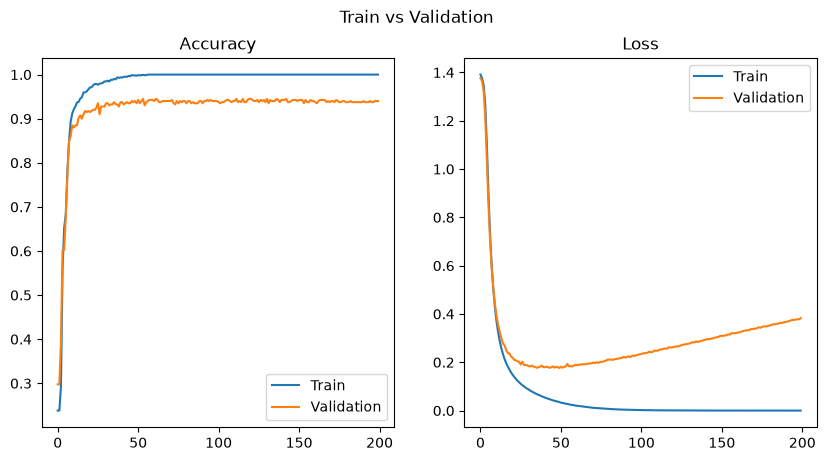

In [8]:
baseline_model = MLP_CSV()
baseline_history = training_loop(mb_train_loader, mb_test_loader, baseline_model)
plot_result(baseline_history)

### 2.) ให้ทดลอง train โมเดลโดยใช้ L2 Regularizer เพิ่มในข้อ 1.) รวมทั้งหมด 2 แบบ คือ
  1. ใช้ L2 แบบ Marginal loss โดย `lambda` = [0.03, 0.01, 0.005] (เพิ่ม L2 loss ใน Training loop)
  2. ใช้ L2 แบบ Weight decay โดย `weight_decay` = [0.06, 0.01, 0.005] (ปรับ param ใน `optimizer`)

- > แคปรูปผลลัพธ์ใหม่ทั้งหมด 6 รูป พร้อมกับแสดงส่วนที่แก้ไขเพื่อทำ Marginal loss ภายใน Training loop และ วิเคราะห์เปรียบเทียบผลลัพธ์ที่ได้ทั้งหมดกับข้อ 1.)

In [9]:
def run_training(train_dl, test_dl, model, optimizer, l2_coef=0.0, n_epochs=200, scheduler=None):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    loss_fn = nn.CrossEntropyLoss()

    n_show_loss = n_epochs // 10 if n_epochs > 10 else 1
    train_history = {"train_loss":[], "validate_loss":[],
                     "train_acc":[], "validate_acc":[]}
    for epoch in range(n_epochs):
        train_loss, train_correct = 0, 0
        model.train(True)
        for X_t, y_t in train_dl:
            X_t, y_t = X_t.to(device), y_t.to(device)
            optimizer.zero_grad()
            y_pred = model(X_t)
            loss = loss_fn(y_pred, y_t)
            if l2_coef > 0.0:
                l2_penalty = sum(p.pow(2).sum() for p in model.parameters())
                loss = loss + l2_coef * l2_penalty
            else:
                loss = loss
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            train_correct += (y_pred.argmax(1) == y_t).float().sum().item()
        train_history["train_loss"].append(train_loss / len(train_dl))
        train_history["train_acc"].append(train_correct / len(train_dl.dataset))

        valid_loss, valid_correct = 0, 0
        model.eval()
        with torch.no_grad():
            for X_v, y_v in test_dl:
                X_v, y_v = X_v.to(device), y_v.to(device)
                y_predv = model(X_v)
                vloss = loss_fn(y_predv.squeeze(), y_v.squeeze())
                valid_loss += vloss.item()
                valid_correct += (y_predv.argmax(1) == y_v).float().sum().item()
        train_history["validate_loss"].append(valid_loss / len(test_dl))
        train_history["validate_acc"].append(valid_correct / len(test_dl.dataset))

        if scheduler is not None:
            scheduler.step()

        if ((epoch+1) % n_show_loss == 0) or (epoch == n_epochs-1):
            print(f"Epochs {epoch+1}".ljust(12),
                  f"train loss {train_history['train_loss'][-1]:.6f}",
                  f"valid loss {train_history['validate_loss'][-1]:.6f}",
                  f"train acc {train_history['train_acc'][-1]:.6f}",
                  f"valid acc {train_history['validate_acc'][-1]:.6f}")

    return train_history

--- L2 marginal loss, lambda=0.03 ---
Epochs 20    train loss 1.450168 valid loss 1.387163 train acc 0.251250 valid acc 0.245000
Epochs 40    train loss 1.386715 valid loss 1.388310 train acc 0.258750 valid acc 0.215000
Epochs 60    train loss 1.386425 valid loss 1.388829 train acc 0.258750 valid acc 0.215000
Epochs 80    train loss 1.386323 valid loss 1.389122 train acc 0.258750 valid acc 0.215000
Epochs 100   train loss 1.386240 valid loss 1.389306 train acc 0.258750 valid acc 0.215000
Epochs 120   train loss 1.386184 valid loss 1.389372 train acc 0.258750 valid acc 0.215000
Epochs 140   train loss 1.386127 valid loss 1.389409 train acc 0.258750 valid acc 0.215000
Epochs 160   train loss 1.386093 valid loss 1.389445 train acc 0.258750 valid acc 0.215000
Epochs 180   train loss 1.386064 valid loss 1.389456 train acc 0.258750 valid acc 0.215000
Epochs 200   train loss 1.386060 valid loss 1.389442 train acc 0.258750 valid acc 0.215000
--- L2 marginal loss, lambda=0.01 ---
Epochs 20    t

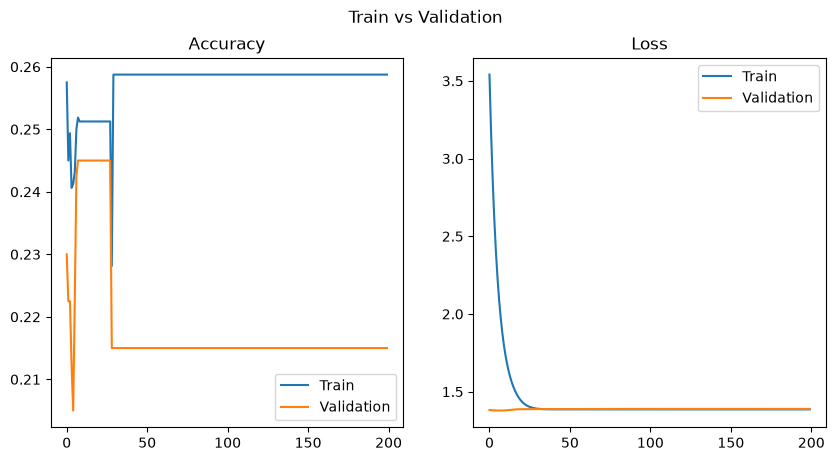

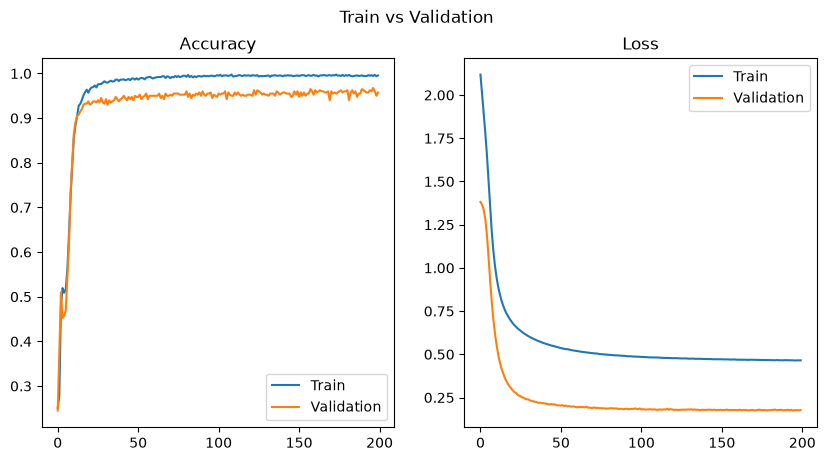

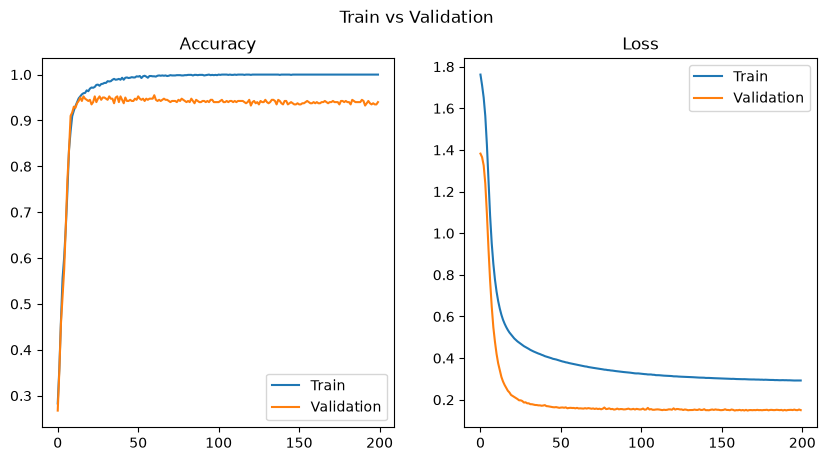

In [10]:
# HW 2.1: L2 as a marginal loss term added by hand inside run_training (l2_coef > 0)
marginal_histories = {}
for coef in [0.03, 0.01, 0.005]:
    print(f"--- L2 marginal loss, lambda={coef} ---")
    model = MLP_CSV()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    history = run_training(mb_train_loader, mb_test_loader, model, optimizer, l2_coef=coef)
    marginal_histories[coef] = history
    plot_result(history)

--- Weight decay, weight_decay=0.06 ---
Epochs 20    train loss 1.040372 valid loss 0.999987 train acc 0.510000 valid acc 0.460000
Epochs 40    train loss 0.471285 valid loss 0.489116 train acc 0.910000 valid acc 0.900000
Epochs 60    train loss 0.412003 valid loss 0.429016 train acc 0.935625 valid acc 0.912500
Epochs 80    train loss 0.398281 valid loss 0.415995 train acc 0.932500 valid acc 0.935000
Epochs 100   train loss 0.391199 valid loss 0.407936 train acc 0.935625 valid acc 0.922500
Epochs 120   train loss 0.387624 valid loss 0.404667 train acc 0.938125 valid acc 0.922500
Epochs 140   train loss 0.384959 valid loss 0.400373 train acc 0.938125 valid acc 0.935000
Epochs 160   train loss 0.382894 valid loss 0.400751 train acc 0.939375 valid acc 0.947500
Epochs 180   train loss 0.381393 valid loss 0.396215 train acc 0.940000 valid acc 0.925000
Epochs 200   train loss 0.378604 valid loss 0.397165 train acc 0.940000 valid acc 0.945000
--- Weight decay, weight_decay=0.01 ---
Epochs 20 

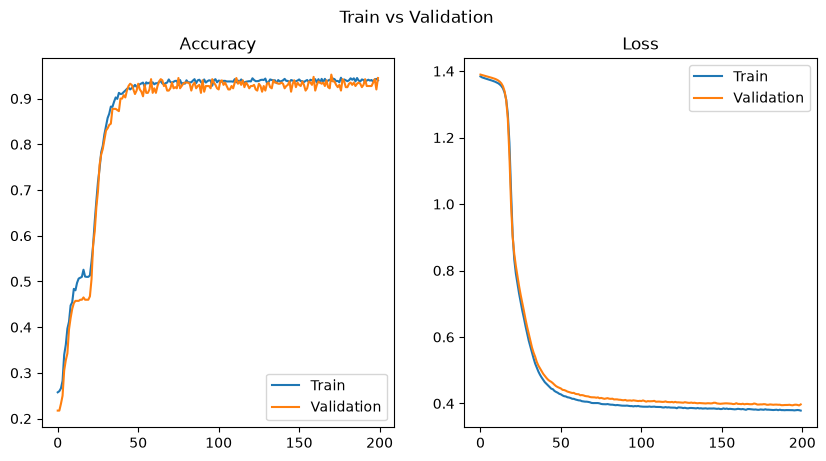

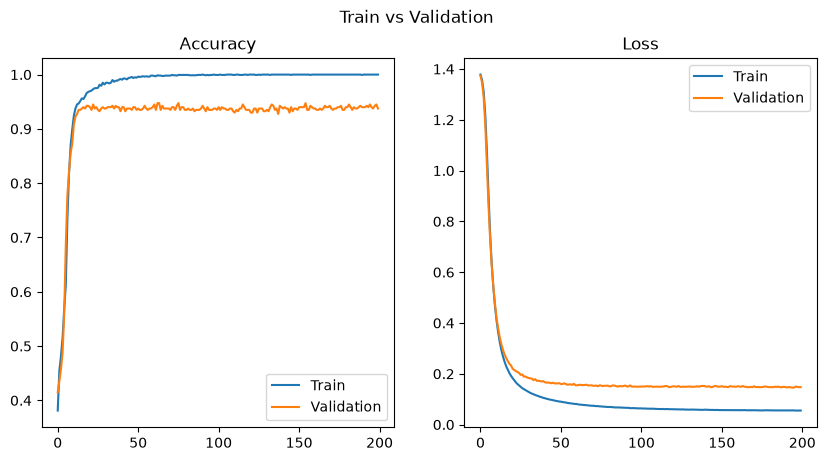

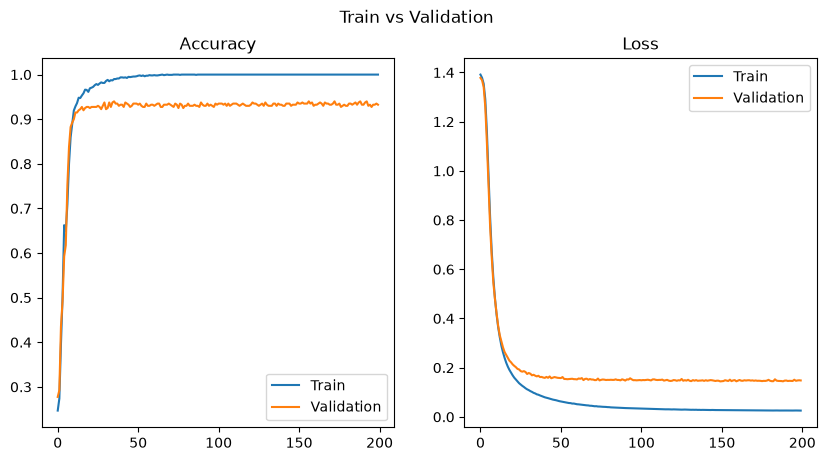

In [11]:
# HW 2.2: L2 via the optimizer's own weight_decay (l2_coef left at its default 0.0)
wd_histories = {}
for wd in [0.06, 0.01, 0.005]:
    print(f"--- Weight decay, weight_decay={wd} ---")
    model = MLP_CSV()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=wd)
    history = run_training(mb_train_loader, mb_test_loader, model, optimizer)
    wd_histories[wd] = history
    plot_result(history)

**เปรียบเทียบกับผลลัพธ์ Baseline (ข้อ 1):**

จากกราฟ Baseline จะเห็นว่าโมเดล overfit ชัดเจน - train loss ลดลงจนเกือบเป็น 0 ในขณะที่เส้น valid loss กลับสูงขึ้นเรื่อยๆ ในช่วงหลัง (train accuracy ขึ้นไปเกือบ 100% แต่ valid accuracy ไม่ได้ตามไปด้วย)

พอเพิ่ม L2 เข้าไป ไม่ว่าจะเป็นแบบ Marginal loss หรือ Weight decay จะเห็นว่าเส้น train กับ valid loss ใกล้เเคียงกันมากขึ้น model overfit น้อยลง

ถ้าลองไล่ดูตามค่า `lambda` หรือ `weight_decay` ที่มากขึ้นยิ่งค่ามาก model จะถูกบังคับให้ weight เล็กลงมากขึ้น กราฟ train/valid ก็จะยิ่งเกาะกันแน่น

โดยสรุป ทั้งสองวิธีของ L2 ช่วยลด overfitting ได้ในทิศทางเดียวกัน และยิ่งค่า regularization สูง ก็ยิ่งควบคุม overfitting ได้มากขึ้นตามไปด้วย

### 3.) ให้ทดลอง train โมเดลโดยใช้ Dropout เพิ่มในข้อ 1.) ภายในชั้น fc1, fc2 และ fc3 และแทนค่า `p` ในแต่ละชั้นเป็นค่าดังต่อไปนี้
  1. fc1, fc2, fc3 = 0.5, 0.3, 0.2
  2. fc1, fc2, fc3 = 0.3, 0.2, 0.1
  3. fc1, fc2, fc3 = 0.2, 0.2, 0.2

- > แคปรูปผลลัพธ์ใหม่ทั้งหมด 3 รูป และ วิเคราะห์เปรียบเทียบผลลัพธ์ที่ได้กับข้อ 1.)

In [12]:
class MLP_CSV_Dropout(nn.Module):
    def __init__(self, p1, p2, p3):
        super(MLP_CSV_Dropout, self).__init__()
        self.fc1 = nn.Sequential(
            nn.Linear(in_features=20, out_features=128),
            nn.ReLU(),
            nn.Dropout(p=p1),
        )
        self.fc2 = nn.Sequential(
            nn.Linear(in_features=128, out_features=64),
            nn.ReLU(),
            nn.Dropout(p=p2),
        )
        self.fc3 = nn.Sequential(
            nn.Linear(in_features=64, out_features=32),
            nn.ReLU(),
            nn.Dropout(p=p3),
        )
        self.out = nn.Linear(in_features=32, out_features=4)

    def forward(self, x):
        x = self.fc1(x)
        x = self.fc2(x)
        x = self.fc3(x)
        x = self.out(x)
        return x

--- Dropout p1=0.5, p2=0.3, p3=0.2 ---
Epochs 20    train loss 0.592423 valid loss 0.461796 train acc 0.751875 valid acc 0.847500
Epochs 40    train loss 0.441043 valid loss 0.277467 train acc 0.801250 valid acc 0.895000
Epochs 60    train loss 0.362049 valid loss 0.221643 train acc 0.857500 valid acc 0.915000
Epochs 80    train loss 0.321660 valid loss 0.198247 train acc 0.868750 valid acc 0.917500
Epochs 100   train loss 0.284270 valid loss 0.182409 train acc 0.883750 valid acc 0.927500
Epochs 120   train loss 0.244091 valid loss 0.165938 train acc 0.906250 valid acc 0.935000
Epochs 140   train loss 0.213511 valid loss 0.165825 train acc 0.914375 valid acc 0.940000
Epochs 160   train loss 0.205835 valid loss 0.166282 train acc 0.919375 valid acc 0.937500
Epochs 180   train loss 0.186403 valid loss 0.158880 train acc 0.933125 valid acc 0.937500
Epochs 200   train loss 0.173344 valid loss 0.158199 train acc 0.931875 valid acc 0.932500
--- Dropout p1=0.3, p2=0.2, p3=0.1 ---
Epochs 20   

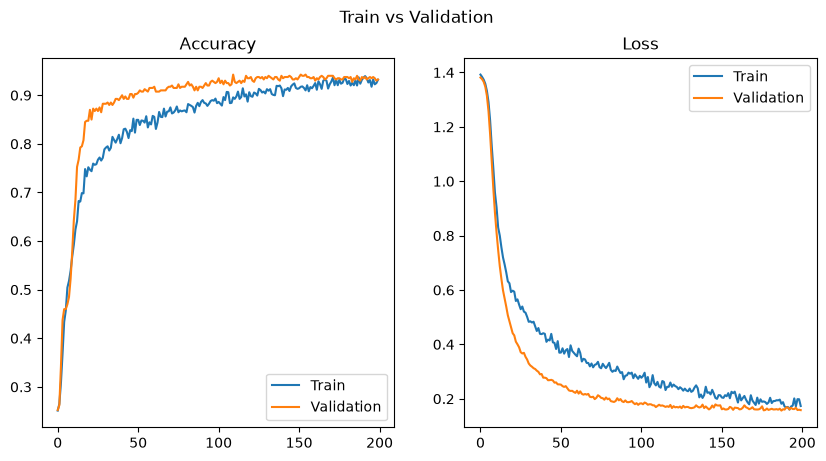

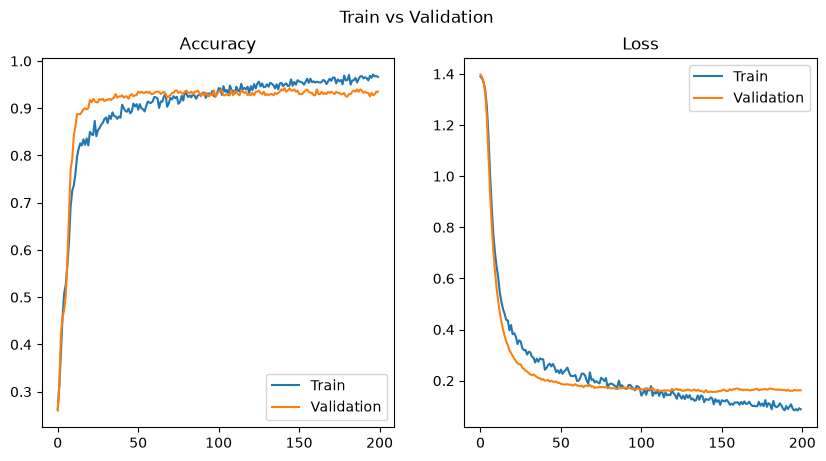

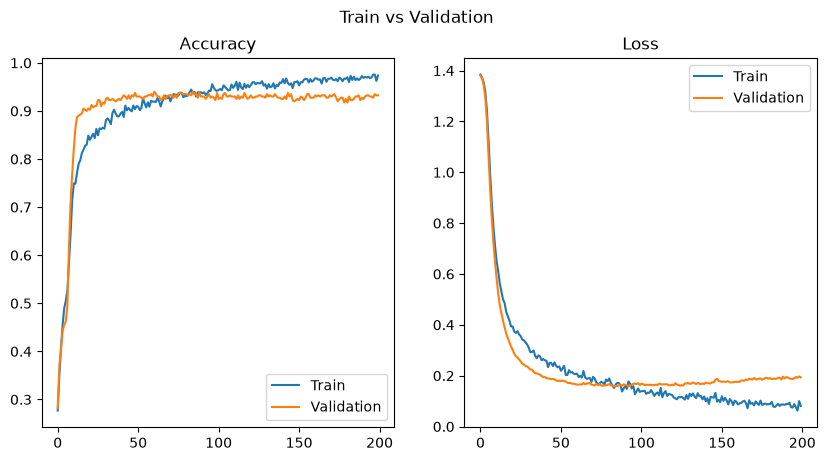

In [13]:
dropout_histories = {}
for p1, p2, p3 in [(0.5, 0.3, 0.2), (0.3, 0.2, 0.1), (0.2, 0.2, 0.2)]:
    print(f"--- Dropout p1={p1}, p2={p2}, p3={p3} ---")
    model = MLP_CSV_Dropout(p1, p2, p3)
    history = training_loop(mb_train_loader, mb_test_loader, model)
    dropout_histories[(p1, p2, p3)] = history
    plot_result(history)

**เปรียบเทียบกับผลลัพธ์ Baseline (ข้อ 1):**

ทั้ง 3 ค่าของ Dropout ที่ลองช่วยลด overfitting ได้ชัดเจนเมื่อเทียบกับ Baseline

ถ้าใช้ Dropout ค่าสูง (เช่น 0.5/0.3/0.2) โมเดลจะเทรนช้ากว่า เส้น accuracy ขึ้นช้ากว่าชาวบ้าน แต่ก็ควบคุม overfitting ได้ดีกว่า ส่วนถ้าใช้ Dropout ค่าน้อยและเท่ากันทุกชั้น (0.2/0.2/0.2) โมเดลจะเทรนได้เร็วกว่าและได้ valid accuracy ที่ดีที่สุดในบรรดา 3 แบบนี้ เพราะ regularize กำลังพอดีกับจำนวน epoch ที่มี ไม่มากไม่น้อยเกินไป

โดยรวมแล้ว Dropout ช่วยแก้ปัญหา overfitting ได้ดั

### 4.) ให้ทดลอง train โมเดล `MLP_CSV` ต้นแบบจากข้อ 1.) อีกครั้ง พร้อมกับ train โมเดลที่ใช้ BatchNorm เพิ่มในข้อ 1.) ภายในชั้น fc1, fc2 และ fc3 (ใช้ `nn.BatchNorm1d`) แต่จะมีการปรับในส่วนการเตรียม Mobile price Dataset ดังนี้
  1. โมเดลที่ใช้ BatchNorm ใช้ Dataset ที่ **ผ่าน** การทำ Standardized ด้วย `StandardScaler()` เทียบกับผลลัพธ์ข้อ 1.)
  2. โมเดล `MLP_CSV` ต้นแบบจากข้อ 1.) ใช้ Dataset ที่ **ไม่ผ่าน** การทำ Standardized
  3. โมเดลที่ใช้ BatchNorm ใช้ Dataset ที่ **ไม่ผ่าน** การทำ Standardized เทียบกับผลลัพธ์ข้อ 4.2)

- > แคปรูปผลลัพธ์ใหม่ทั้งหมด 3 รูป และ วิเคราะห์เปรียบเทียบผลลัพธ์ที่ได้

In [14]:
class MLP_CSV_BN(nn.Module):
    def __init__(self):
        super(MLP_CSV_BN, self).__init__()
        self.fc1 = nn.Sequential(
            nn.Linear(in_features=20, out_features=128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
        )
        self.fc2 = nn.Sequential(
            nn.Linear(in_features=128, out_features=64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
        )
        self.fc3 = nn.Sequential(
            nn.Linear(in_features=64, out_features=32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
        )
        self.out = nn.Linear(in_features=32, out_features=4)

    def forward(self, x):
        x = self.fc1(x)
        x = self.fc2(x)
        x = self.fc3(x)
        x = self.out(x)
        return x

In [15]:
# Non-standardized copy of the mobile price dataset/loaders (mirrors cell 5, but skips StandardScaler).
# mb_X / mb_train_loader / mb_test_loader from cell 5 stay untouched.
mb_X_raw = mobile_df.drop(columns=['price_range']).values.astype(np.float32)
mb_y_raw = mobile_df.price_range.values

mb_X_raw = torch.tensor(mb_X_raw)
mb_y_raw = torch.tensor(mb_y_raw)

mb_train_set_raw = TensorDataset(mb_X_raw, mb_y_raw)
mb_train_size_raw = int(train_split * len(mb_train_set_raw))
mb_test_size_raw = len(mb_train_set_raw) - mb_train_size_raw
mb_train_set_raw, mb_test_set_raw = torch.utils.data.random_split(mb_train_set_raw, [mb_train_size_raw, mb_test_size_raw])

mb_train_loader_raw = DataLoader(mb_train_set_raw, batch_size=16, shuffle=True)
mb_test_loader_raw = DataLoader(mb_test_set_raw, batch_size=16, shuffle=True)

print(len(mb_train_set_raw), len(mb_test_set_raw))
print(len(mb_train_loader_raw), len(mb_test_loader_raw))

1600 400
100 25


Epochs 20    train loss 0.556623 valid loss 0.564433 train acc 0.810000 valid acc 0.837500
Epochs 40    train loss 0.418923 valid loss 0.412338 train acc 0.830000 valid acc 0.855000
Epochs 60    train loss 0.356336 valid loss 0.407896 train acc 0.865000 valid acc 0.830000
Epochs 80    train loss 0.326821 valid loss 0.408034 train acc 0.876875 valid acc 0.822500
Epochs 100   train loss 0.272759 valid loss 0.459957 train acc 0.898750 valid acc 0.792500
Epochs 120   train loss 0.220305 valid loss 0.517731 train acc 0.922500 valid acc 0.760000
Epochs 140   train loss 0.216645 valid loss 0.514909 train acc 0.919375 valid acc 0.760000
Epochs 160   train loss 0.208497 valid loss 0.581949 train acc 0.922500 valid acc 0.732500
Epochs 180   train loss 0.190564 valid loss 0.597902 train acc 0.929375 valid acc 0.742500
Epochs 200   train loss 0.162261 valid loss 0.632122 train acc 0.945625 valid acc 0.750000


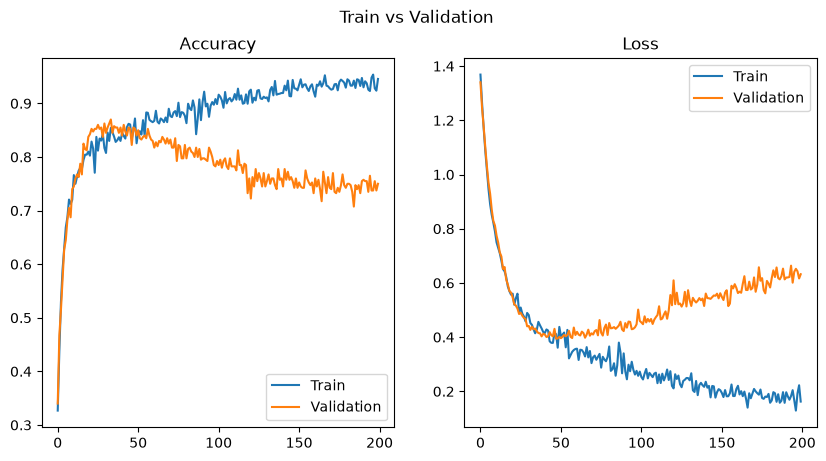

In [16]:
# 4.1: MLP_CSV_BN on the standardized data
bn_std_model = MLP_CSV_BN()
bn_std_history = training_loop(mb_train_loader, mb_test_loader, bn_std_model)
plot_result(bn_std_history)

Epochs 20    train loss 0.709067 valid loss 0.761647 train acc 0.668125 valid acc 0.680000
Epochs 40    train loss 0.686538 valid loss 0.729511 train acc 0.683125 valid acc 0.685000
Epochs 60    train loss 0.594195 valid loss 0.618810 train acc 0.717500 valid acc 0.717500
Epochs 80    train loss 0.568737 valid loss 0.653689 train acc 0.731250 valid acc 0.700000
Epochs 100   train loss 0.555313 valid loss 0.653098 train acc 0.731875 valid acc 0.717500
Epochs 120   train loss 0.541979 valid loss 0.650309 train acc 0.744375 valid acc 0.705000
Epochs 140   train loss 0.519916 valid loss 0.565808 train acc 0.767500 valid acc 0.752500
Epochs 160   train loss 0.515509 valid loss 0.633605 train acc 0.767500 valid acc 0.730000
Epochs 180   train loss 0.485154 valid loss 0.571349 train acc 0.778750 valid acc 0.765000
Epochs 200   train loss 0.450888 valid loss 0.666043 train acc 0.798750 valid acc 0.720000


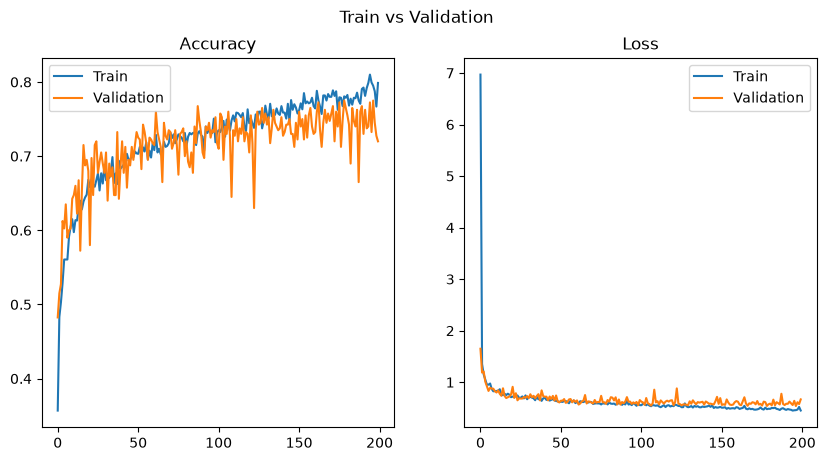

In [17]:
# 4.2: plain MLP_CSV on the raw (non-standardized) data
raw_baseline_model = MLP_CSV()
raw_baseline_history = training_loop(mb_train_loader_raw, mb_test_loader_raw, raw_baseline_model)
plot_result(raw_baseline_history)

Epochs 20    train loss 0.451884 valid loss 0.297547 train acc 0.826250 valid acc 0.940000
Epochs 40    train loss 0.456862 valid loss 0.262385 train acc 0.808125 valid acc 0.945000
Epochs 60    train loss 0.376759 valid loss 0.250029 train acc 0.856250 valid acc 0.947500
Epochs 80    train loss 0.372258 valid loss 0.242239 train acc 0.848125 valid acc 0.960000
Epochs 100   train loss 0.375949 valid loss 0.235273 train acc 0.850000 valid acc 0.945000
Epochs 120   train loss 0.356690 valid loss 0.237285 train acc 0.851250 valid acc 0.922500
Epochs 140   train loss 0.373690 valid loss 0.242804 train acc 0.846875 valid acc 0.912500
Epochs 160   train loss 0.342755 valid loss 0.233592 train acc 0.873750 valid acc 0.942500
Epochs 180   train loss 0.330193 valid loss 0.216725 train acc 0.865000 valid acc 0.930000
Epochs 200   train loss 0.297187 valid loss 0.224085 train acc 0.880625 valid acc 0.932500


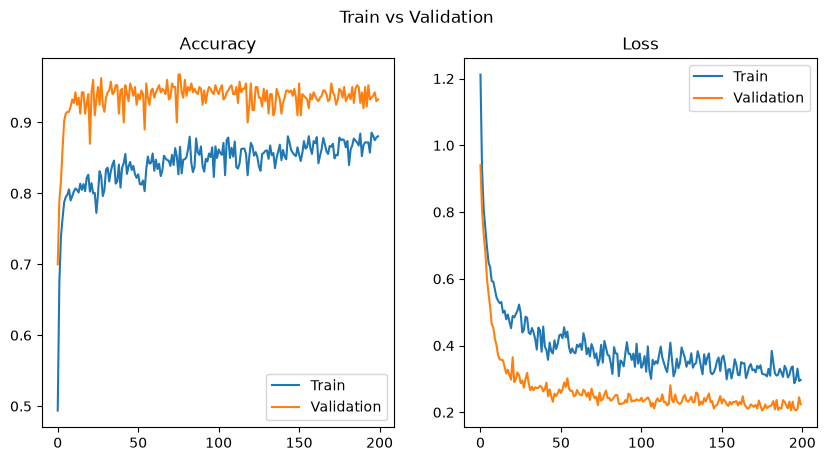

In [18]:
# 4.3: MLP_CSV_BN on the raw (non-standardized) data
bn_raw_model = MLP_CSV_BN()
bn_raw_history = training_loop(mb_train_loader_raw, mb_test_loader_raw, bn_raw_model)
plot_result(bn_raw_history)

**เปรียบเทียบทั้ง 4.1/4.2/4.3 และย้อนกลับไปดูข้อ 1:**

**4.1 เทียบกับ Baseline:** พอเอา BatchNorm ไปใส่บนข้อมูลที่ standardize มาแล้ว ผลกลับแย่ลงกว่า Baseline แทนที่จะดีขึ้น — เส้น valid loss แกว่งไม่นิ่งและมีแนวโน้มสูงขึ้นเรื่อย ๆ ส่วน valid accuracy ก็ต่ำกว่า Baseline ชัดเจน สาเหตุน่าจะมาจาก batch size ที่เล็ก (16) ทำให้ค่าสถิติที่ BatchNorm คำนวณในแต่ละ batch มี noise สูง และในเมื่อข้อมูล standardize มาก่อนหน้าอยู่แล้ว การ normalize ซ้ำอีกชั้นจึงไม่ได้ช่วยอะไร กลับทำให้เทรนไม่นิ่งแทน

**4.2 (Baseline บนข้อมูลดิบ):** พอไม่ standardize ข้อมูลเลย โมเดล `MLP_CSV` ธรรมดาจะเทรนได้แย่ลงชัดเจน ทั้ง train accuracy และ valid accuracy ต่ำกว่าตอนที่ standardize มาก เพราะฟีเจอร์แต่ละตัวมีสเกลต่างกันมาก (เช่น `ram` มีค่าเป็นพัน แต่ `clock_speed` มีค่าแค่หลักหน่วย) ทำให้ optimizer ปรับ weight ได้ไม่ดี

**4.3 เทียบกับ 4.2:** พอเพิ่ม BatchNorm เข้าไปในโมเดลที่เทรนบนข้อมูลดิบ ผลลัพธ์ดีขึ้นชัดเจนมาก - valid accuracy ขยับขึ้นไปใกล้เคียงกับตอนที่ standardize ข้อมูลเอง (ใกล้เคียง Baseline ข้อ 1) และ valid loss ก็นิ่งและต่ำกว่า 4.2 มาก แสดงว่า BatchNorm ช่วยทดแทนการทำ StandardScaler ได้จริง เมื่อข้อมูลที่ป้อนเข้ายังไม่ได้ปรับสเกลมาก่อน

BatchNorm จะช่วยได้มากเมื่อข้อมูลยังไม่ได้ standardize (4.3 ดีกว่า 4.2 ชัดเจน) แต่ถ้าข้อมูล standardize มาอยู่แล้ว การใส่ BatchNorm ซ้ำเข้าไปอาจไม่ช่วยหรือกลับทำให้แย่ลงได้ (4.1 แย่กว่า Baseline)

### 5.) ให้ทำการสร้าง Dataset ที่ใช้การ `transforms` เพิ่มเติมจากที่กำหนดไว้ โดยให้ลดขนาดภาพลงเหลือ 8x8 pixels (64 features) และเพิ่มการ Transform อีกอย่างน้อย 1 แบบ พร้อมกับสร้าง Dataloaders ที่มีจำนวน train : test = 80 : 20 ของจำนวน Dataset ทั้งหมดและใช้ `batch_size` = 16
* > แคปรูปส่วนกำหนดการ transforms และการทำ Dataloaders

In [19]:
import torchvision
from torchvision.transforms import v2

mnist_transforms = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Resize((8, 8)),
    v2.Normalize(mean=[0.5], std=[0.5]),
])

mnist_train_data = torchvision.datasets.MNIST('./Image/train_directory/', transform=mnist_transforms, download=True, train=True)
mnist_test_data = torchvision.datasets.MNIST('./Image/test_directory/', transform=mnist_transforms, download=True, train=False)

mnist_full_dataset = torch.utils.data.ConcatDataset([mnist_train_data, mnist_test_data])

mnist_train_split = 0.8
mnist_train_size = int(mnist_train_split * len(mnist_full_dataset))
mnist_valid_size = len(mnist_full_dataset) - mnist_train_size
mnist_train_set, mnist_valid_set = torch.utils.data.random_split(mnist_full_dataset, [mnist_train_size, mnist_valid_size])

mnist_train_loader = DataLoader(mnist_train_set, batch_size=16, shuffle=True)
mnist_valid_loader = DataLoader(mnist_valid_set, batch_size=16, shuffle=True)

print(len(mnist_train_set), len(mnist_valid_set))
print(len(mnist_train_loader), len(mnist_valid_loader))

56000 14000
3500 875


### 6.) ให้ทดลอง train โมเดล `MLP_MNIST` ต้นแบบที่กำหนด และ train โมเดลที่นักศึกษาออกแบบเอง (หรือเพิ่มต่อจากต้นแบบก็ได้) โดยกำหนดให้เพิ่มส่วนเทคนิคการใช้ L2 Regularizer, Dropout และ BatchNorm ภายในโมเดลที่ออกแบบเอง (เลือกอย่างน้อย 2 เทคนิค จะใส่ในทุก Hidden layers หรือไม่ก็ได้)

กำหนดไว้ว่าโมเดลที่นักศึกษาออกแบบ จะสามารถปรับจำนวน features ภายในได้อิสระ แต่ต้องมีจำนวน Hidden layers เท่ากับ `MLP_MNIST` ต้นแบบ และกำหนดการ train จะต้องใช้จำนวน `epochs` เท่ากัน โดยเลือกเองให้ <= 50, `optimizer` เลือกเอง และสามารถใช้ Learning rate scheduler ได้

* > จงทดลองหาผลลัพธ์การทำงาน ที่ทำให้ได้ประสิทธิภาพสูงกว่า `MLP_MNIST` ต้นแบบ เช่น Accuracy สูงกว่าเดิม
>
> แคปรูปผลลัพธ์การทำงาน โครงสร้างโมเดลสุดท้าย และอธิบายว่าใช้เทคนิคอะไร ทำอย่างไรบ้างที่ทำให้ได้ประสิทธิภาพสูงขึ้น

Epochs 2     train loss 1.004436 valid loss 0.799267 train acc 0.702929 valid acc 0.779143
Epochs 4     train loss 0.572635 valid loss 0.540614 train acc 0.831196 valid acc 0.838571
Epochs 6     train loss 0.496981 valid loss 0.486267 train acc 0.852804 valid acc 0.852357
Epochs 8     train loss 0.459876 valid loss 0.454682 train acc 0.863696 valid acc 0.864000
Epochs 10    train loss 0.433416 valid loss 0.431280 train acc 0.871750 valid acc 0.871214
Epochs 12    train loss 0.412888 valid loss 0.415902 train acc 0.876946 valid acc 0.871857
Epochs 14    train loss 0.395020 valid loss 0.393281 train acc 0.883000 valid acc 0.881143
Epochs 16    train loss 0.380028 valid loss 0.389349 train acc 0.886321 valid acc 0.884143
Epochs 18    train loss 0.365052 valid loss 0.378302 train acc 0.891125 valid acc 0.885643
Epochs 20    train loss 0.351017 valid loss 0.347358 train acc 0.895018 valid acc 0.895286


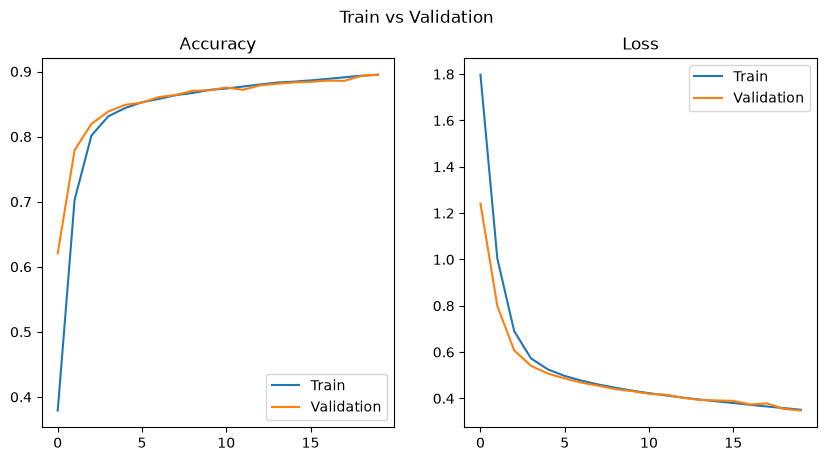

In [20]:
# Baseline MLP_MNIST, unmodified training_loop
mnist_baseline_model = MLP_MNIST()
mnist_baseline_history = training_loop(mnist_train_loader, mnist_valid_loader, mnist_baseline_model, n_epochs=20)
plot_result(mnist_baseline_history)

In [21]:
class MLP_MNIST_Custom(nn.Module):
    def __init__(self):
        super(MLP_MNIST_Custom, self).__init__()
        self.fc1 = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=8*8, out_features=64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(p=0.3),
        )
        self.fc2 = nn.Sequential(
            nn.Linear(in_features=64, out_features=32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(p=0.2),
        )
        self.fc3 = nn.Sequential(
            nn.Linear(in_features=32, out_features=16),
            nn.BatchNorm1d(16),
            nn.ReLU(),
        )
        self.out = nn.Linear(in_features=16, out_features=10)

    def forward(self, x):
        x = self.fc1(x)
        x = self.fc2(x)
        x = self.fc3(x)
        x = self.out(x)
        return x

Epochs 2     train loss 0.505492 valid loss 0.215149 train acc 0.845089 valid acc 0.936857
Epochs 4     train loss 0.432739 valid loss 0.183634 train acc 0.867232 valid acc 0.945571
Epochs 6     train loss 0.408436 valid loss 0.171612 train acc 0.875964 valid acc 0.949357
Epochs 8     train loss 0.388486 valid loss 0.160278 train acc 0.880089 valid acc 0.952000
Epochs 10    train loss 0.380556 valid loss 0.160913 train acc 0.882268 valid acc 0.952714
Epochs 12    train loss 0.352759 valid loss 0.153847 train acc 0.892464 valid acc 0.955071
Epochs 14    train loss 0.350078 valid loss 0.152348 train acc 0.893554 valid acc 0.953786
Epochs 16    train loss 0.343671 valid loss 0.145432 train acc 0.893643 valid acc 0.956071
Epochs 18    train loss 0.341229 valid loss 0.147863 train acc 0.894446 valid acc 0.955000
Epochs 20    train loss 0.345165 valid loss 0.148032 train acc 0.894232 valid acc 0.956143


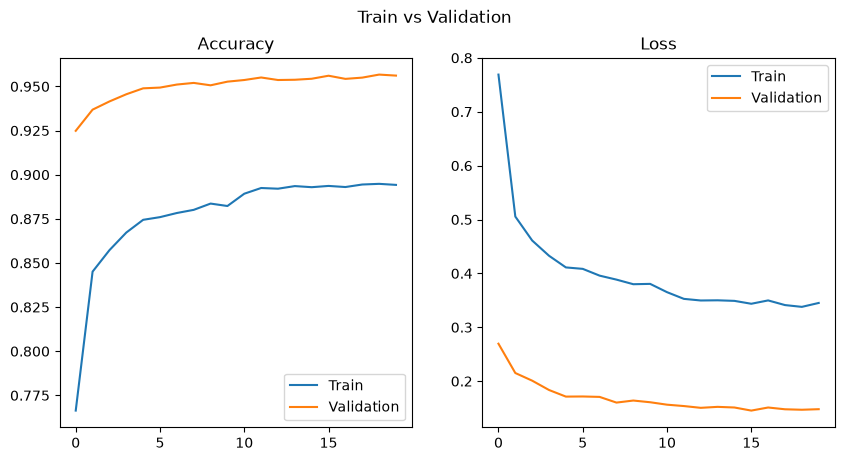

In [22]:
# Custom model, trained via the same run_training used in HW-2, now exercising its scheduler argument
mnist_custom_model = MLP_MNIST_Custom()
mnist_custom_optimizer = torch.optim.AdamW(mnist_custom_model.parameters(), lr=1e-3)
mnist_custom_scheduler = torch.optim.lr_scheduler.StepLR(mnist_custom_optimizer, step_size=10, gamma=0.5)
mnist_custom_history = run_training(mnist_train_loader, mnist_valid_loader, mnist_custom_model,
                                     mnist_custom_optimizer, n_epochs=20, scheduler=mnist_custom_scheduler)
plot_result(mnist_custom_history)

**เปรียบเทียบ Baseline กับโมเดลที่ออกแบบเอง:**

โมเดล `MLP_MNIST_Custom` ให้ valid accuracy สูงกว่า Baseline อย่างเห็นได้ชัด ทั้งที่จำนวน hidden layer และจำนวน epoch เท่ากัน แม้ train accuracy ของทั้งสองโมเดลจะใกล้เคียงกันมาก valid loss ของ Baseline ยังลดลงเรื่อยๆ ในขณะที่ของ Custom ลดลงเร็วกว่ามากและนิ่งกว่าตั้งแต่ช่วงต้น อีกทั้งบางช่วง valid loss ยังต่ำกว่า train loss ด้วยซ้ำ ซึ่งเป็นสัญญาณของ Dropout ที่ทำงานตอนเทรน (ทำให้ train loss ดูสูงกว่าที่ควร) แต่จะปิดตอน evaluate

เทคนิคที่ใช้ในโมเดล Custom มี 2 อย่าง ใส่ทั้งใน fc1 และ fc2:
- **BatchNorm1d** ต่อจาก `Linear` ก่อนเข้า `ReLU` — ช่วยให้ optimize ได้เร็วและนิ่งขึ้น ทำให้ loss ลดเร็วกว่าในจำนวน epoch เท่ากัน
- **Dropout** ต่อจาก `ReLU` — ช่วย regularize โดยปิด activation แบบสุ่มตอนเทรน ทำให้โมเดลไม่ overfit ง่าย ผลที่ได้คือ generalize ดีขึ้น (valid accuracy สูงขึ้น) แม้ train accuracy จะดูไม่ต่างจาก Baseline มากก็ตาม

นอกจากนี้ยังใช้ `AdamW` (มี weight decay แบบ decoupled) ร่วมกับ `StepLR` scheduler (ลด learning rate ลงครึ่งหนึ่งทุก ๆ 10 epoch) แทน `Adam` ธรรมดาของ Baseline ซึ่งช่วยให้เทรนได้เร็วและนิ่งขึ้นภายในจำนวน epoch ที่จำกัดเท่ากัน